# Casablanca Healthcare Accessibility (preprocessed WorldPop + route-based network)

This notebook focuses on the accessibility analysis itself. Raster clipping, origin extraction, and transport preprocessing are handled upstream in the preprocessing notebooks.

It still outputs district-level summaries for mapping and reporting.


## 1) Imports and paths

In [1]:
from __future__ import annotations

from pathlib import Path
from dataclasses import dataclass
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
from scipy.spatial import cKDTree
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 250)

PROJECT_ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == "notebooks" else Path.cwd().resolve()

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DATA_INTERIM = PROJECT_ROOT / "data" / "interim"
DATA_FINAL = PROJECT_ROOT / "data" / "final"
FIG_DIR = PROJECT_ROOT / "outputs" / "figures"

for p in [DATA_INTERIM, DATA_FINAL, FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# Required main inputs
DISTRICTS_PATH = DATA_PROCESSED / "districts_with_worldpop.gpkg"
ORIGINS_GPKG_PATH = DATA_INTERIM / "worldpop_origins.gpkg"
HEALTHCARE_PATH = DATA_PROCESSED / "Casablanca_Healthcare.gpkg"
TRANSPORT_STOPS_PATH = DATA_PROCESSED / "Casablanca_Transport_Route_Stops.gpkg"
TRANSPORT_ROUTE_VERTICES_PATH = DATA_PROCESSED / "Casablanca_Transport_Route_Vertices.gpkg"

# Outputs
ORIGINS_CSV_PATH = DATA_INTERIM / "worldpop_origins.csv"
ORIGIN_METRICS_CSV_PATH = DATA_INTERIM / "origin_accessibility_metrics.csv"
DISTRICT_SUMMARY_CSV_PATH = DATA_FINAL / "district_accessibility_summary.csv"
DISTRICT_SUMMARY_GPKG_PATH = DATA_FINAL / "district_accessibility_summary.gpkg"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("Districts:", DISTRICTS_PATH)
print("WorldPop origins:", ORIGINS_GPKG_PATH)
print("Transport stops:", TRANSPORT_STOPS_PATH)
print("Transport route vertices:", TRANSPORT_ROUTE_VERTICES_PATH)


PROJECT_ROOT: D:\Capstone\capstone_repo
Districts: D:\Capstone\capstone_repo\data\processed\districts_with_worldpop.gpkg
WorldPop origins: D:\Capstone\capstone_repo\data\interim\worldpop_origins.gpkg
Transport stops: D:\Capstone\capstone_repo\data\processed\Casablanca_Transport_Route_Stops.gpkg
Transport route vertices: D:\Capstone\capstone_repo\data\processed\Casablanca_Transport_Route_Vertices.gpkg


## 2) Constants and assumptions

In [2]:
@dataclass
class Config:
    target_crs: str = "EPSG:32629"       # metric CRS for accurate distances
    walking_speed_kmh: float = 3.6        
    transit_speed_kmh: float = 20.0       
    wait_time_min: float = 10.0           
    catchment_min: float = 30.0           # 2SFCA Gaussian catchment
    accessibility_max_time_min: float = 60.0  
    max_facility_walk_m: float = 1000.0
    max_origins: int = 120_000
    aggregation_grid_m: float = 200.0
    threshold_min: float = 30.0

cfg = Config()

WALK_M_MIN = cfg.walking_speed_kmh * 1000 / 60
TRANSIT_M_MIN = cfg.transit_speed_kmh * 1000 / 60

print(f"Walking speed: {cfg.walking_speed_kmh} km/h ({WALK_M_MIN:.2f} m/min)")
print(f"Transit speed: {cfg.transit_speed_kmh} km/h ({TRANSIT_M_MIN:.2f} m/min)")
print(f"Wait time: {cfg.wait_time_min} min")
print(f"Accessibility score max time (single definition): {cfg.accessibility_max_time_min} min")
print(f"2SFCA catchment: {cfg.catchment_min} min")

Walking speed: 3.6 km/h (60.00 m/min)
Transit speed: 20.0 km/h (333.33 m/min)
Wait time: 10.0 min
Accessibility score max time (single definition): 60.0 min
2SFCA catchment: 30.0 min


## 3) Utility functions

In [3]:
def ensure_exists(path: Path, label: str):
    """Check that a file exists, raise an error if not."""
    if not path.exists():
        raise FileNotFoundError(f"Missing {label}: {path}")

def detect_district_cols(gdf: gpd.GeoDataFrame):
    """Detect district name and ID columns in a GeoDataFrame, adding them if missing."""
    name_col = next((c for c in ["district", "commune", "district_name", "name"] if c in gdf.columns), None)
    id_col = next((c for c in ["district_id", "id", "district_idx", "OBJECTID"] if c in gdf.columns), None)
    if name_col is None:
        gdf["district_name"] = [f"district_{i}" for i in range(len(gdf))]
        name_col = "district_name"
    if id_col is None:
        gdf["district_id"] = np.arange(len(gdf)).astype(int)
        id_col = "district_id"
    return id_col, name_col

def accessibility_score(travel_time_min: float, max_time_min: float) -> float:
    """Calculate accessibility score based on travel time."""
    if not np.isfinite(travel_time_min):
        return np.nan
    return float(max(0.0, 100.0 * (1.0 - min(travel_time_min / max_time_min, 1.0))))

def gaussian_decay(travel_time_min: float, catchment_min: float) -> float:
    """
        Calculate Gaussian decay weight based on travel time and catchment.
        Used for: 2SFCA method to weight healthcare facility influence by travel time.
    """
    return float(np.exp(-((travel_time_min / catchment_min) ** 2)))

def weighted_mean(values: pd.Series, weights: pd.Series) -> float:
    """
        Calculate weighted mean, ignoring non-finite values and zero weights.
        Used for: aggregating accessibility metrics.
    """
    v = values.to_numpy(dtype=float)
    w = weights.to_numpy(dtype=float)
    m = np.isfinite(v) & np.isfinite(w) & (w > 0)
    if m.sum() == 0:
        return np.nan
    return float(np.average(v[m], weights=w[m]))

## 4) Load Data: Districts, origin points, transport data

###  Load Districts


In [4]:
# Load districts data
ensure_exists(DISTRICTS_PATH, "district polygons")

districts_raw = gpd.read_file(DISTRICTS_PATH)
if districts_raw.empty:
    raise ValueError("districts_with_worldpop.gpkg is empty")
if districts_raw.crs is None:
    raise ValueError("districts_with_worldpop.gpkg has no CRS")

# Detect district ID and name columns, adding them if missing
did_col, dname_col = detect_district_cols(districts_raw)
districts = districts_raw[[did_col, dname_col, "geometry"]].rename(
    columns={did_col: "district_id", dname_col: "district_name"}
).copy()
districts["district_id"] = districts["district_id"].astype(str)
districts["district_name"] = districts["district_name"].astype(str)

print(f"Districts loaded: {len(districts):,}")

Districts loaded: 34


### Load origin points

In [5]:
# Load origins data
ensure_exists(ORIGINS_GPKG_PATH, "WorldPop origins")

origins = gpd.read_file(ORIGINS_GPKG_PATH, layer="origins")
if origins.empty:
    raise ValueError("worldpop_origins.gpkg is empty")
if origins.crs is None:
    raise ValueError("worldpop_origins.gpkg has no CRS")

# Ensure origins have necessary columns and CRS, assigning districts if needed
origins = origins.to_crs(cfg.target_crs)
if "x" not in origins.columns:
    origins["x"] = origins.geometry.x
if "y" not in origins.columns:
    origins["y"] = origins.geometry.y

if {"district_id", "district_name"}.issubset(origins.columns):
    origins["district_id"] = origins["district_id"].astype(str)
    origins["district_name"] = origins["district_name"].astype(str)
else:
    district_metric = districts.to_crs(cfg.target_crs)
    origins = gpd.sjoin(origins, district_metric, how="inner", predicate="within").drop(columns=["index_right"], errors="ignore")
    if origins.empty:
        raise ValueError("No origins assigned to districts")
    origins["district_id"] = origins["district_id"].astype(str)
    origins["district_name"] = origins["district_name"].astype(str)

origins = origins.sort_values("origin_id").reset_index(drop=True)

print(f"Origins loaded: {len(origins):,}")
print(f"Total retained population: {origins['population'].sum():,.2f}")
origins.head(2)


Origins loaded: 117,107
Total retained population: 4,285,216.00


,origin_id,x,y,population,district,commune,commune_type_encoded,population_worldpop,pop_mean_pixel,pop_max_pixel,area_km2,pop_density_km2,geometry,district_id,district_name
0,0,650955.569217,3.727034e+06,22.828148,Tit Mellil,Echchallalate,0,367061.46875,38.351423,689.361328,68.428257,5364.179726,POINT (650955.569 3727033.913),32,Tit Mellil
1,1,650879.762233,3.726940e+06,20.102985,Tit Mellil,Echchallalate,0,367061.46875,38.351423,689.361328,68.428257,5364.179726,POINT (650879.762 3726940.288),32,Tit Mellil


### Build raster-origin points with population weights

In [6]:
# Origins are precomputed upstream; keep a stable order for downstream analysis.
origins = origins.reset_index(drop=True)
print(f"Valid origin points kept: {len(origins):,}")
print(f"Total population retained after preprocessing: {origins['population'].sum():,.2f}")

Valid origin points kept: 117,107
Total population retained after preprocessing: 4,285,216.00


### Transport Data: Stops & Routes


In [7]:
ensure_exists(TRANSPORT_STOPS_PATH, "transport stops")
ensure_exists(TRANSPORT_ROUTE_VERTICES_PATH, "transport route vertices")

route_stops_gdf = gpd.read_file(TRANSPORT_STOPS_PATH, layer="route_stops")
if route_stops_gdf.empty:
    raise ValueError("Casablanca_Transport_Route_Stops.gpkg is empty")
if route_stops_gdf.crs is None:
    raise ValueError("Casablanca_Transport_Route_Stops.gpkg has no CRS")
route_stops_gdf = route_stops_gdf.to_crs(cfg.target_crs)
route_stops_gdf = route_stops_gdf[[c for c in ["stop_key", "stop_id", "stop_name", "mode", "geometry"] if c in route_stops_gdf.columns]].copy()
route_stops_gdf["stop_key"] = route_stops_gdf["stop_key"].astype(str)
route_stops_gdf["stop_id"] = route_stops_gdf["stop_id"].astype(str)
route_stops_gdf["mode"] = route_stops_gdf["mode"].astype(str)

route_vertices_gdf = gpd.read_file(TRANSPORT_ROUTE_VERTICES_PATH, layer="route_vertices")
if route_vertices_gdf.empty:
    raise ValueError("Casablanca_Transport_Route_Vertices.gpkg is empty")
if route_vertices_gdf.crs is None:
    raise ValueError("Casablanca_Transport_Route_Vertices.gpkg has no CRS")
route_vertices_gdf = route_vertices_gdf.to_crs(cfg.target_crs)
if "route_id" not in route_vertices_gdf.columns or "vertex_order" not in route_vertices_gdf.columns:
    raise ValueError("Route vertices must include route_id and vertex_order columns")
route_vertices_gdf["route_id"] = route_vertices_gdf["route_id"].astype(str)
route_vertices_gdf["vertex_order"] = route_vertices_gdf["vertex_order"].astype(int)
route_vertices_gdf = route_vertices_gdf.sort_values(["route_id", "vertex_order"]).reset_index(drop=True)
if "x" not in route_vertices_gdf.columns:
    route_vertices_gdf["x"] = route_vertices_gdf.geometry.x
if "y" not in route_vertices_gdf.columns:
    route_vertices_gdf["y"] = route_vertices_gdf.geometry.y

print(f"Route vertices loaded: {len(route_vertices_gdf):,}")
print(f"Route stops loaded: {len(route_stops_gdf):,}")
route_stops_gdf.head()


Route vertices loaded: 40,762
Route stops loaded: 1,478


,stop_key,stop_id,stop_name,mode,geometry
0,cluster_0_casabus,cluster_0,112 Boulevard D'Anfa,casabus,POINT (626755.86 3717761.903)
1,cluster_1_casabus,cluster_1,112 Boulevard D'Anfa,casabus,POINT (626795.695 3717771.079)
2,cluster_2_casabus,cluster_2,4EME ARRONDISSEMENT,casabus,POINT (632501.75 3713965.612)
3,cluster_3_casabus,cluster_3,4EME ARRONDISSEMENT,casabus,POINT (632421.048 3714023.148)
4,cluster_4_casabus,cluster_4,ABATOIRS MUNICIPAUX,casabus,POINT (634637.356 3713159.658)


### Load healthcare and transport-stop datasets used in accessibility computation

In [8]:
id_col="facility_id"
ensure_exists(HEALTHCARE_PATH, f"points file {HEALTHCARE_PATH.name}")

# Load healthcare facilities, supporting both CSV (with lon/lat) and geospatial formats, ensuring CRS and ID column.
if HEALTHCARE_PATH.suffix.lower() == ".csv":
    healthcare_df = pd.read_csv(HEALTHCARE_PATH)
    lon_col = next((c for c in ["longitude", "lon", "x", "Location.Longitude"] if c in healthcare_df.columns), None)
    lat_col = next((c for c in ["latitude", "lat", "y", "Location.Latitude"] if c in healthcare_df.columns), None)
    if lon_col is None or lat_col is None:
        raise ValueError(f"CSV {HEALTHCARE_PATH} missing lon/lat columns")
    healthcare = gpd.GeoDataFrame(healthcare_df, geometry=gpd.points_from_xy(healthcare_df[lon_col], healthcare_df[lat_col]), crs="EPSG:4326")
else:
    healthcare = gpd.read_file(HEALTHCARE_PATH)
    if healthcare.crs is None:
        raise ValueError(f"No CRS in {HEALTHCARE_PATH}")
if id_col not in healthcare.columns:
    healthcare[id_col] = np.arange(len(healthcare)).astype(int)
healthcare = healthcare[[id_col, "geometry"]].copy().to_crs(cfg.target_crs)


print(f"Healthcare facilities: {len(healthcare):,}")

Healthcare facilities: 83


## 5) Build route-based transport graph 

Important:
- Edges come from **sequential route polyline vertices**.
- Stops are snapped to nearest route vertices (within tolerance), then linked to route network.

### Route Nodes and Edges

In [9]:
G = nx.Graph()

# Build route-vertex nodes and edges from route vertices
route_vertex_rows = []
for rid, group in route_vertices_gdf.groupby("route_id", sort=False):
    group = group.sort_values("vertex_order")
    coords = group[["x", "y"]].to_numpy(dtype=np.float64)
    if len(coords) < 2:
        continue

    vertex_names = []
    for i, (x, y) in enumerate(coords):
        vname = f"r{rid}_v{i}"
        G.add_node(vname, kind="route_vertex", x=x, y=y, route_id=rid)
        route_vertex_rows.append((vname, x, y, rid))
        vertex_names.append(vname)

    for i in range(len(coords) - 1):
        u = vertex_names[i]
        v = vertex_names[i + 1]
        d = float(np.hypot(coords[i + 1][0] - coords[i][0], coords[i + 1][1] - coords[i][1]))
        t_min = d / TRANSIT_M_MIN
        G.add_edge(u, v, weight=t_min, distance_m=d, mode="transit", route_id=rid)

route_vertices_df = pd.DataFrame(route_vertex_rows, columns=["vertex", "x", "y", "route_id"])
route_vertices_xy = route_vertices_df[["x", "y"]].to_numpy(dtype=np.float64)
route_tree = cKDTree(route_vertices_xy)

In [10]:
# Add stop nodes and connect each stop to nearest route vertex (transfer/walk edge)
stop_xy = np.column_stack([route_stops_gdf.geometry.x.values, route_stops_gdf.geometry.y.values]).astype(np.float64)
d_stop_route, idx_stop_route = route_tree.query(stop_xy, k=1, workers=-1)

for i, srow in route_stops_gdf.reset_index(drop=True).iterrows():
    skey = str(srow["stop_key"])
    sx, sy = float(srow.geometry.x), float(srow.geometry.y)
    G.add_node(f"stop_{skey}", kind="stop", x=sx, y=sy, mode=srow["mode"], stop_id=str(srow["stop_id"]))
    vname = route_vertices_df.iloc[int(idx_stop_route[i])]["vertex"]
    d = float(d_stop_route[i])
    walk_t = d / WALK_M_MIN
    G.add_edge(f"stop_{skey}", vname, weight=walk_t, distance_m=d, mode="transfer")

print(f"Graph nodes: {G.number_of_nodes():,}")
print(f"Graph edges: {G.number_of_edges():,}")
print("Note: Connectivity now follows preprocessed route sequences, not arbitrary stop proximity.")

Graph nodes: 42,240
Graph edges: 42,175
Note: Connectivity now follows preprocessed route sequences, not arbitrary stop proximity.


In [11]:
# Define maximum walking distance (in meters) to allow transfers between stops
transfer_radius_m = 150      

# Extract stop coordinates as a NumPy array [x, y]
stop_coords = np.column_stack([
    route_stops_gdf.geometry.x.values,
    route_stops_gdf.geometry.y.values
]).astype(np.float64)

# Extract stop identifiers as strings
stop_keys = route_stops_gdf["stop_key"].astype(str).values

# Build a KD-tree for efficient spatial neighbor search
stop_tree_transfer = cKDTree(stop_coords)

# Find all pairs of stops within the transfer radius
pairs = stop_tree_transfer.query_pairs(r=transfer_radius_m)

# Initialize counter for added transfer edges
added_transfer_edges = 0

# Loop through each nearby stop pair
for i, j in pairs:
    # Get stop identifiers for both stops
    skey_i = stop_keys[i]
    skey_j = stop_keys[j]

    # Skip if both stops have the same identifier
    if skey_i == skey_j:
        continue

    # Get coordinates of both stops
    xi, yi = stop_coords[i]
    xj, yj = stop_coords[j]

    # Compute Euclidean distance between stops (in meters)
    d = float(np.hypot(xj - xi, yj - yi))

    # Convert walking distance to time using walking speed
    walk_t = d / WALK_M_MIN

    # Add bidirectional walking transfer edge between stops in the graph
    G.add_edge(
        f"stop_{skey_i}",
        f"stop_{skey_j}",
        weight=walk_t,
        distance_m=d,
        mode="transfer_walk"
    )

    # Increment counter of added edges
    added_transfer_edges += 1

# Print total number of transfer edges added to the graph
print(f"Added {added_transfer_edges:,} stop-to-stop transfer edges")

Added 617 stop-to-stop transfer edges


### Connect healthcare facilities to network

In [12]:
# Build array of stop coordinates [x, y] for spatial indexing
stop_xy = np.column_stack([
    route_stops_gdf.geometry.x.values,
    route_stops_gdf.geometry.y.values
]).astype(np.float64)

# Build KD-tree for efficient nearest-neighbor and radius queries
stop_tree = cKDTree(stop_xy)

# Loop through each healthcare facility
for _, hrow in healthcare.iterrows():
    # Extract facility ID and coordinates
    fid = str(hrow["facility_id"])
    hx, hy = float(hrow.geometry.x), float(hrow.geometry.y)

    # Create a unique node ID for the facility
    hnode = f"fac_{fid}"

    # Add facility node to the graph
    G.add_node(hnode, kind="facility", x=hx, y=hy)

    # Find nearby stops within walking radius
    idxs = stop_tree.query_ball_point([hx, hy], r=cfg.max_facility_walk_m)

    # If no stops are within radius, connect to the nearest stop
    if len(idxs) == 0:
        d, j = stop_tree.query([hx, hy], k=1)
        idxs = [int(j)] if np.isfinite(d) else []

    # Create walking edges from facility to nearby stops
    for s_idx in idxs:
        # Get stop identifier and coordinates
        skey = str(route_stops_gdf.iloc[int(s_idx)]["stop_key"])
        sx, sy = float(route_stops_gdf.iloc[int(s_idx)].geometry.x), float(route_stops_gdf.iloc[int(s_idx)].geometry.y)

        # Compute Euclidean distance between facility and stop
        d = float(np.hypot(hx - sx, hy - sy))

        # Convert walking distance to travel time
        walk_t = d / WALK_M_MIN

        # Add edge representing walking connection to the graph
        G.add_edge(
            hnode,
            f"stop_{skey}",
            weight=walk_t,
            distance_m=d,
            mode="walk"
        )

# Print final graph size after linking healthcare facilities
print(f"Graph after healthcare linking: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")

Graph after healthcare linking: 42,323 nodes, 44,746 edges


## 6) Compute origin-level travel times and accessibility

This section computes the minimum travel time from each population-weighted origin to all healthcare facilities using the constructed multimodal transport network.

For each origin, the k nearest public transport stops are identified using a KD-tree. Instead of considering only the closest stop, multiple candidate stops are evaluated.

Shortest path travel times from candidate stops to all healthcare facilities are precomputed using **Dijkstra’s algorithm**. For each origin, the total travel time is calculated as the sum of walking time to the stop, waiting time, and in-vehicle travel time.

The best stop (the one minimizing travel time to the nearest facility) is selected.

The output includes: total travel time, nearest facility, accessibility score, and number of reachable facilities within given thresholds for each origin.

In [13]:
# Number of nearest stops to evaluate for each origin
k_origin_stops = 5  

# Extract origin coordinates as NumPy array [x, y]
origin_xy = np.column_stack([
    origins.geometry.x.values,
    origins.geometry.y.values
]).astype(np.float64)

# Query k nearest stops for each origin using KD-tree
dists_k, idxs_k = stop_tree.query(origin_xy, k=k_origin_stops, workers=-1)

# Ensure outputs are 2D even when k=1
if k_origin_stops == 1:
    dists_k = dists_k[:, None]
    idxs_k = idxs_k[:, None]

# Reset index for consistent row access
origins = origins.reset_index(drop=True)

# Extract all facility IDs
facility_ids = healthcare["facility_id"].astype(str).values

Precompute stop -> facility travel times

In [14]:
# Get all unique candidate stops across all origins
all_candidate_stop_idxs = np.unique(idxs_k.ravel())

# Get corresponding stop keys
candidate_stop_keys = route_stops_gdf.iloc[all_candidate_stop_idxs]["stop_key"].astype(str).values

# Dictionary to store shortest travel time from each stop to each facility
stop_to_fac_times = {}

# Loop through candidate stops
for skey in candidate_stop_keys:
    src = f"stop_{skey}"

    # If stop is not in graph, assign infinite travel times
    if src not in G:
        stop_to_fac_times[skey] = {fid: np.inf for fid in facility_ids}
        continue

    # Compute shortest path distances from this stop to all nodes
    lengths = nx.single_source_dijkstra_path_length(G, src, weight="weight")

    # Store travel time to each facility
    stop_to_fac_times[skey] = {
        fid: lengths.get(f"fac_{fid}", np.inf) for fid in facility_ids
    }

Initialize Outputs

In [15]:
# Number of origins and facilities
n_origins = len(origins)
n_facilities = len(facility_ids)

# Matrix storing travel time from each origin to each facility
origin_travel_times = np.full((n_origins, n_facilities), np.inf, dtype=np.float32)

# Arrays to store best stop information per origin
best_stop_keys = np.full(n_origins, None, dtype=object)
best_stop_walk_dist = np.full(n_origins, np.inf, dtype=np.float32)
best_stop_walk_time = np.full(n_origins, np.inf, dtype=np.float32)

Compute best travel time per origin

In [16]:
# Loop through each origin
for i in range(n_origins):
    # Initialize best travel times for this origin
    best_times_row = np.full(n_facilities, np.inf, dtype=np.float32)

    # Evaluate each of the k nearest stops
    for c in range(k_origin_stops):
        stop_idx = int(idxs_k[i, c])
        walk_d = float(dists_k[i, c])

        # Skip invalid distances
        if not np.isfinite(walk_d):
            continue

        # Get stop key
        skey = str(route_stops_gdf.iloc[stop_idx]["stop_key"])

        # Compute walking time to stop
        walk_t = walk_d / WALK_M_MIN

        # Get precomputed stop → facility times
        fac_times_dict = stop_to_fac_times.get(skey, None)
        if fac_times_dict is None:
            continue

        # Compute total travel time = walk + wait + transport
        candidate_times = np.array([
            walk_t + cfg.wait_time_min + fac_times_dict[fid]
            if np.isfinite(fac_times_dict[fid]) else np.inf
            for fid in facility_ids
        ], dtype=np.float32)

        # Update best times if improved
        improved = candidate_times < best_times_row
        best_times_row[improved] = candidate_times[improved]

    # Store best times for this origin
    origin_travel_times[i, :] = best_times_row

Identify best stop per origin

In [17]:
# Identify best stop per origin (must loop over all origins, not only the last one)
for i in range(n_origins):
    if not np.isfinite(origin_travel_times[i, :]).any():
        continue

    best_candidate = np.inf
    best_skey = None
    best_walk_d = np.inf
    best_walk_t = np.inf

    for c in range(k_origin_stops):
        stop_idx = int(idxs_k[i, c])
        walk_d = float(dists_k[i, c])
        if not np.isfinite(walk_d):
            continue

        skey = str(route_stops_gdf.iloc[stop_idx]["stop_key"])
        fac_times_dict = stop_to_fac_times.get(skey, None)
        if fac_times_dict is None:
            continue

        walk_t = walk_d / WALK_M_MIN
        candidate_best = min(
            (
                walk_t + cfg.wait_time_min + fac_times_dict[fid]
                for fid in facility_ids
                if np.isfinite(fac_times_dict[fid])
            ),
            default=np.inf,
        )

        if np.isfinite(candidate_best) and candidate_best < best_candidate:
            best_candidate = candidate_best
            best_skey = skey
            best_walk_d = walk_d
            best_walk_t = walk_t

    if best_skey is not None:
        best_stop_keys[i] = best_skey
        best_stop_walk_dist[i] = np.float32(best_walk_d)
        best_stop_walk_time[i] = np.float32(best_walk_t)

Final Outputs and metrics

In [18]:
# Identify nearest facility index for each origin
nearest_idx = np.argmin(origin_travel_times, axis=1)

# Extract corresponding travel time
nearest_time = origin_travel_times[np.arange(n_origins), nearest_idx]

# Store results in GeoDataFrame
origins["chosen_stop_key"] = best_stop_keys
origins["walk_dist_to_stop_m"] = best_stop_walk_dist
origins["walk_time_to_stop_min"] = best_stop_walk_time

# Assign nearest facility ID
origins["nearest_facility_id"] = [
    facility_ids[j] if np.isfinite(nearest_time[i]) else None
    for i, j in enumerate(nearest_idx)
]

# Store total travel time
origins["total_travel_time_min"] = nearest_time.astype(np.float32)

Accessibility Metric

In [19]:
# Safe wrapper for accessibility score
def safe_accessibility_score(t, max_time):
    if not np.isfinite(t):
        return 0.0
    return float(accessibility_score(t, max_time))

# Compute accessibility score
origins["accessibility_score"] = origins["total_travel_time_min"].apply(
    lambda t: safe_accessibility_score(t, cfg.accessibility_max_time_min)
).astype(np.float32)

# Count reachable facilities within thresholds
origins["num_facilities_reachable_30min"] = np.sum(origin_travel_times <= 30, axis=1).astype(np.int32)
origins["num_facilities_reachable_60min"] = np.sum(origin_travel_times <= 60, axis=1).astype(np.int32)

# Flag unreachable origins
origins["is_unreachable"] = ~np.isfinite(origins["total_travel_time_min"])

# Print summary
print("Origin travel-time matrix shape:", origin_travel_times.shape)
print("Unreachable origins:", int(origins["is_unreachable"].sum()))
print("Share unreachable:", float(origins["is_unreachable"].mean()))

# Origin travel-time matrix shape: (117107, 83)
# Unreachable origins after k-nearest-stop assignment: 708
# Share unreachable: 0.006045753029280914

Origin travel-time matrix shape: (117107, 83)
Unreachable origins: 708
Share unreachable: 0.006045753029280914


In [20]:
origins[[
    "origin_id",
    "chosen_stop_key",
    "walk_time_to_stop_min",
    "total_travel_time_min",
    "accessibility_score",
    "is_unreachable"
]].head()

,origin_id,chosen_stop_key,walk_time_to_stop_min,total_travel_time_min,accessibility_score,is_unreachable
0,0,cluster_1271_casabus,15.642012,92.599533,0.0,False
1,1,cluster_1271_casabus,16.616528,93.574051,0.0,False
2,2,cluster_1271_casabus,17.058338,94.015862,0.0,False
3,3,cluster_1271_casabus,17.583565,94.541084,0.0,False
4,4,cluster_1271_casabus,17.531780,94.489304,0.0,False


## 7) Two-Step Floating Catchment Area (2SFCA) Accessibility

This section computes accessibility using the Two-Step Floating Catchment Area (2SFCA) method with a distance-decay function.

In the first step, each healthcare facility is assigned a supply-to-demand ratio by considering the population demand from all origins, weighted by travel time using a Gaussian decay function. [populations contribute more strongly to demand than distant ones.]    

ratio R_j = S_j / weighted_demand_j (S_j=1 by default).

In the second step, each origin accumulates accessibility by summing the contributions of all facilities, weighted by the same decay function: Accessibility depends not only on distance but also on how many people compete for the same healthcare resources.

sum R_j * decay(t_ij) over reachable facilities.

In [21]:
# Extract population weights for each origin
pop = origins["population"].to_numpy(dtype=np.float64)

# Define catchment threshold (used in decay function)
catch = cfg.catchment_min

# Compute Gaussian decay weights based on travel time
# Closer facilities receive higher weights
decay_matrix = np.exp(-((origin_travel_times.astype(np.float64) / catch) ** 2))

# Set decay weight to zero for unreachable origin-facility pairs
decay_matrix[~np.isfinite(origin_travel_times)] = 0.0

In [22]:
# Step 1: Facility-level supply-to-demand ratio

# Compute weighted demand at each facility (sum of population × decay weight)
weighted_demand = np.sum((pop[:, None]) * decay_matrix, axis=0)

# Assume equal supply for all facilities (can be replaced with real capacity data)
facility_supply = np.ones(len(facility_ids), dtype=np.float64)

# Compute supply-to-demand ratio for each facility
facility_ratio = np.divide(
    facility_supply,
    weighted_demand,
    out=np.zeros_like(facility_supply),
    where=weighted_demand > 0
)

In [23]:
# Step 2: Origin-level accessibility score

# Compute accessibility score for each origin by summing weighted facility ratios
score_2sfca = np.sum(decay_matrix * facility_ratio[None, :], axis=1)

# Store results in GeoDataFrame
origins["score_2sfca"] = score_2sfca.astype(np.float32)

# Print success completion messange and Preview results
print("2SFCA computed with full origin-facility matrix.")
origins[["origin_id", "score_2sfca"]].head()

2SFCA computed with full origin-facility matrix.


,origin_id,score_2sfca
0,0,9.434478e-10
1,1,7.709755e-10
2,2,7.030579e-10
3,3,6.297048e-10
4,4,6.366000e-10


## 8) Sensitivity Analysis

This section evaluates how sensitive accessibility results are to changes in public transport speed.

A ±20% variation in transit speed is applied to simulate slower and faster network conditions, while keeping walking time and waiting time unchanged. For each scenario, shortest-path travel times from origins to healthcare facilities are recomputed using the same k-nearest-stop assignment strategy.

Results are then aggregated at the district level using population-weighted averages, and changes in district accessibility rankings are analyzed.

Weight function

In [24]:
# Create a custom edge weight function that scales only transit speeds
def make_sensitivity_weight_function(speed_factor: float):
    """
    Returns a weight function where:
    - transit edges are scaled by speed_factor
    - walking/transfer edges remain unchanged
    """
    def weight(u, v, data):
        mode = data.get("mode", "")

        # Recompute travel time for transit edges using adjusted speed
        if mode == "transit":
            d = data.get("distance_m", np.nan)
            if not np.isfinite(d):
                return np.inf
            adjusted_transit_m_min = TRANSIT_M_MIN * speed_factor
            return d / adjusted_transit_m_min

        # Keep walking and transfer edges unchanged
        w = data.get("weight", np.nan)
        return w if np.isfinite(w) else np.inf

    return weight

Precompute stop → facility times

In [25]:
# Precompute shortest travel times from candidate stops to facilities under a given speed scenario
def precompute_stop_to_facility_times_sensitivity(
    G,
    candidate_stop_keys,
    facility_ids,
    speed_factor
):
    # Get modified edge weight function
    weight_func = make_sensitivity_weight_function(speed_factor)

    # Dictionary to store results
    stop_to_fac_times = {}

    # Loop through candidate stops
    for skey in candidate_stop_keys:
        src = f"stop_{skey}"

        # If stop is not in graph, assign infinite travel times
        if src not in G:
            stop_to_fac_times[skey] = {fid: np.inf for fid in facility_ids}
            continue

        # Compute shortest path lengths using modified weights
        lengths = nx.single_source_dijkstra_path_length(G, src, weight=weight_func)

        # Store travel time to each facility
        stop_to_fac_times[skey] = {
            fid: lengths.get(f"fac_{fid}", np.inf)
            for fid in facility_ids
        }

    return stop_to_fac_times

Recompute origin travel times under new speed

In [26]:
# Recompute origin-to-facility travel times for a given speed factor
def run_speed_sensitivity_new(speed_factor: float):

    # Get sizes
    n_origins = len(origins)
    n_facilities = len(facility_ids)
    k_origin_stops = idxs_k.shape[1]

    # Get all candidate stops used in origin assignment
    all_candidate_stop_idxs = np.unique(idxs_k.ravel())
    candidate_stop_keys = route_stops_gdf.iloc[all_candidate_stop_idxs]["stop_key"].astype(str).values

    # Precompute stop → facility travel times under new speed
    stop_to_fac_times = precompute_stop_to_facility_times_sensitivity(
        G=G,
        candidate_stop_keys=candidate_stop_keys,
        facility_ids=facility_ids,
        speed_factor=speed_factor
    )

    # Initialize output vector
    scenario_best_times = np.full(n_origins, np.inf, dtype=np.float32)

    # Loop through each origin
    for i in range(n_origins):
        best = np.inf

        # Evaluate k nearest stops
        for c in range(k_origin_stops):
            stop_idx = int(idxs_k[i, c])

            # Get walking distance to stop
            walk_d = float(dists_k[i, c])
            if not np.isfinite(walk_d):
                continue

            # Get stop key and compute walking time
            skey = str(route_stops_gdf.iloc[stop_idx]["stop_key"])
            walk_t = walk_d / WALK_M_MIN

            # Get stop → facility times
            fac_times_dict = stop_to_fac_times.get(skey, None)
            if fac_times_dict is None:
                continue

            # Compute best reachable facility from this stop
            candidate_best = min(
                (
                    walk_t + cfg.wait_time_min + fac_times_dict[fid]
                    for fid in facility_ids
                    if np.isfinite(fac_times_dict[fid])
                ),
                default=np.inf
            )

            # Keep best travel time across all candidate stops
            if candidate_best < best:
                best = candidate_best

        # Store result (NaN if unreachable)
        scenario_best_times[i] = np.nan if np.isinf(best) else best

    return scenario_best_times

Run scenarios

In [27]:
# Run slower transit scenario (-20%)
print("Running transit speed sensitivity analysis (-20%)...")
origins["tt_slow"] = run_speed_sensitivity_new(0.8)

# Copy base case results
print("Copying base travel times...")
origins["tt_base"] = origins["total_travel_time_min"].astype(np.float32)

# Run faster transit scenario (+20%)
print("Running transit speed sensitivity analysis (+20%)...")
origins["tt_fast"] = run_speed_sensitivity_new(1.2)

Running transit speed sensitivity analysis (-20%)...
Copying base travel times...
Running transit speed sensitivity analysis (+20%)...


Aggregate to district level

In [28]:
# Compute population-weighted average travel time per district
def district_weighted_sensitivity(df, col):
    pop = df["population"].astype(float)
    total_pop = pop.sum()

    # Return NaN if no population
    if total_pop <= 0:
        return np.nan

    # Replace missing travel times with max threshold
    return np.average(
        df[col].fillna(cfg.accessibility_max_time_min),
        weights=pop
    )

# Aggregate results per district
sensitivity = origins.groupby(["district_id", "district_name"]).apply(
    lambda df: pd.Series({
        "tt_slow": district_weighted_sensitivity(df, "tt_slow"),
        "tt_base": district_weighted_sensitivity(df, "tt_base"),
        "tt_fast": district_weighted_sensitivity(df, "tt_fast"),
    })
).reset_index()

C:\Users\afafb\AppData\Local\Temp\ipykernel_20956\3652198068.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sensitivity = origins.groupby(["district_id", "district_name"]).apply(


Ranking changes

In [29]:
# Compute rankings (lower travel time = better)
for c in ["tt_slow", "tt_base", "tt_fast"]:
    sensitivity[f"rank_{c}"] = sensitivity[c].rank(method="min", ascending=True)

# Compute rank changes compared to base
sensitivity["rank_change_slow_vs_base"] = sensitivity["rank_tt_slow"] - sensitivity["rank_tt_base"]
sensitivity["rank_change_fast_vs_base"] = sensitivity["rank_tt_fast"] - sensitivity["rank_tt_base"]

# Select key columns
rank_change_df = sensitivity[[
    "district_id",
    "district_name",
    "rank_change_slow_vs_base",
    "rank_change_fast_vs_base",
    "tt_slow",
    "tt_base",
    "tt_fast"
]].copy()

# Display top changes
print("\nSensitivity analysis (transit speed ±20%) ranking changes:")
display(rank_change_df.sort_values("rank_change_slow_vs_base", ascending=False).head(10))


Sensitivity analysis (transit speed ±20%) ranking changes:


,district_id,district_name,rank_change_slow_vs_base,rank_change_fast_vs_base,tt_slow,tt_base,tt_fast
1,1,Bouskoura,2.0,1.0,64.448665,57.577138,52.821155
17,24,Salmia,1.0,0.0,73.953345,65.439400,59.754041
28,4,Ahl Laghlam,1.0,1.0,38.486373,36.276264,34.736238
16,23,Nouaceur,1.0,1.0,127.773512,110.371314,98.742981
23,3,Mediouna,1.0,1.0,43.917989,39.572069,36.619354
24,30,Sidi Othmane,1.0,0.0,24.266946,23.060276,22.189652
12,2,Mediouna,1.0,1.0,80.635827,71.194364,64.839108
11,19,Mediouna,1.0,0.0,77.977700,67.363883,60.264465
27,33,Tit Mellil,1.0,3.0,66.196371,63.087663,60.975136
30,6,Ain Harrouda,1.0,1.0,38.569326,36.701264,35.395736


Visualization

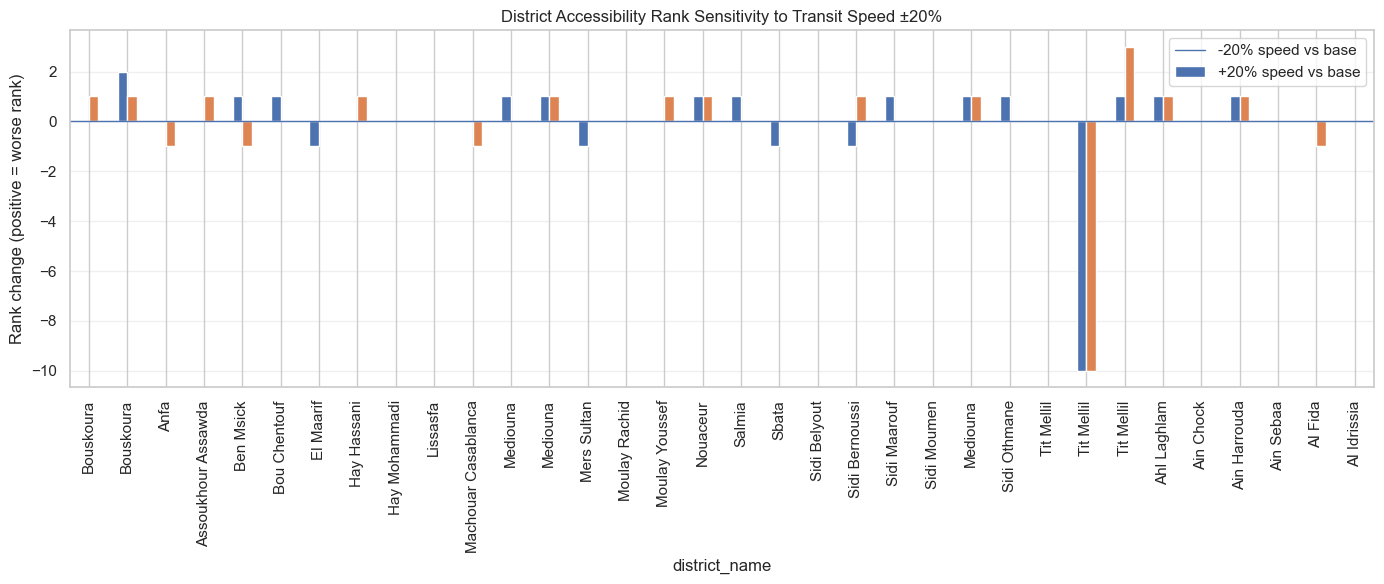

In [30]:
# Plot ranking changes
fig, ax = plt.subplots(figsize=(14, 6))

plot_df = rank_change_df.set_index("district_name")[[
    "rank_change_slow_vs_base",
    "rank_change_fast_vs_base"
]]

plot_df.plot(kind="bar", ax=ax)

# Add reference line
ax.axhline(0, linewidth=1)

# Labels and title
ax.set_ylabel("Rank change (positive = worse rank)")
ax.set_title("District Accessibility Rank Sensitivity to Transit Speed ±20%")

# Legend
ax.legend(["-20% speed vs base", "+20% speed vs base"])

# Grid for readability
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 9) District-level summaries

This section aggregates origin-level accessibility results to the district level using population-weighted metrics.

First, each origin is classified according to whether it can reach a healthcare facility within the defined travel-time threshold. 

Then, for each district, summary indicators are computed using the population associated with each origin as weights. These indicators include average walking time to the nearest stop, average total travel time to healthcare, population-weighted accessibility scores, 2SFCA scores, and the share of population meeting selected accessibility conditions.

In [31]:
# Flag origins that can reach a facility within the accessibility threshold
origins["is_access_threshold"] = (origins["total_travel_time_min"] <= cfg.threshold_min).astype(np.int32)

# Define a function to compute district-level population-weighted metrics
def agg_metrics(df: pd.DataFrame) -> pd.Series:
    # Extract origin population weights
    p = df["population"]

    # Compute total district population represented by raster-based origins
    total_p = float(p.sum())

    # Return empty/default values if district has no population
    if total_p <= 0:
        return pd.Series({
            "population_raster": 0.0,
            "origin_count": int(len(df)),
            "avg_walk_time_to_stop_min_pw": np.nan,
            "avg_total_travel_time_min_pw": np.nan,
            "pop_weighted_accessibility_score": np.nan,
            "pop_weighted_score_2sfca": np.nan,
            "pct_pop_access_threshold": np.nan,
            "pct_pop_score_below_50": np.nan,
        })

    # Compute population-weighted district metrics
    return pd.Series({
        "population_raster": total_p,
        "origin_count": int(len(df)),
        "avg_walk_time_to_stop_min_pw": weighted_mean(df["walk_time_to_stop_min"], p),
        "avg_total_travel_time_min_pw": weighted_mean(df["total_travel_time_min"], p),
        "pop_weighted_accessibility_score": weighted_mean(df["accessibility_score"], p),
        "pop_weighted_score_2sfca": weighted_mean(df["score_2sfca"], p),
        "pct_pop_access_threshold": float(100.0 * (df["is_access_threshold"] * p).sum() / total_p),
        "pct_pop_score_below_50": float(100.0 * p[df["accessibility_score"] < 50].sum() / total_p),
    })


# Aggregate origin-level results to district level
district_summary = origins.groupby(
    ["district_id", "district_name"],
    as_index=False
).apply(agg_metrics).reset_index(drop=True)

# Sort districts by population-weighted accessibility score (highest first)
district_summary = district_summary.sort_values(
    "pop_weighted_accessibility_score",
    ascending=False
)

# Merge aggregated indicators back to district geometries for mapping/export
districts_out = districts.merge(
    district_summary,
    on=["district_id", "district_name"],
    how="left"
)

# Preview the top-ranked districts
district_summary.head(10)

C:\Users\afafb\AppData\Local\Temp\ipykernel_20956\247441989.py:42: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(agg_metrics).reset_index(drop=True)


,district_id,district_name,population_raster,origin_count,avg_walk_time_to_stop_min_pw,avg_total_travel_time_min_pw,pop_weighted_accessibility_score,pop_weighted_score_2sfca,pct_pop_access_threshold,pct_pop_score_below_50
5,13,Bou Chentouf,29411.693359,322.0,3.833672,17.988767,70.018722,0.000058,99.999999,0.000000
6,14,El Maarif,137460.062500,1776.0,4.482419,18.007699,69.987169,0.000069,99.943519,0.056486
8,16,Hay Mohammadi,91473.882812,637.0,4.841141,19.447728,67.587120,0.000028,98.814650,1.185351
15,22,Moulay Youssef,14125.606445,503.0,4.799535,20.002301,66.668828,0.000075,95.935520,4.064480
4,12,Ben Msick,84406.671875,479.0,3.153777,20.237733,66.270444,0.000035,99.773507,0.226492
13,20,Mers Sultan,17214.408203,286.0,4.421337,20.335551,66.107414,0.000069,99.999996,0.000000
33,9,Al Idrissia,27723.011719,249.0,3.738809,20.674167,65.543054,0.000042,99.999997,0.000000
19,26,Sidi Belyout,65050.007812,1167.0,4.660947,20.981568,65.030720,0.000069,92.694070,7.305924
3,11,Assoukhour Assawda,145178.093750,1207.0,4.551923,22.007445,63.320924,0.000041,94.986086,5.013911
2,10,Anfa,73818.453125,2543.0,5.318311,22.051924,63.246794,0.000064,87.211974,12.788025


## 10) Visualizations

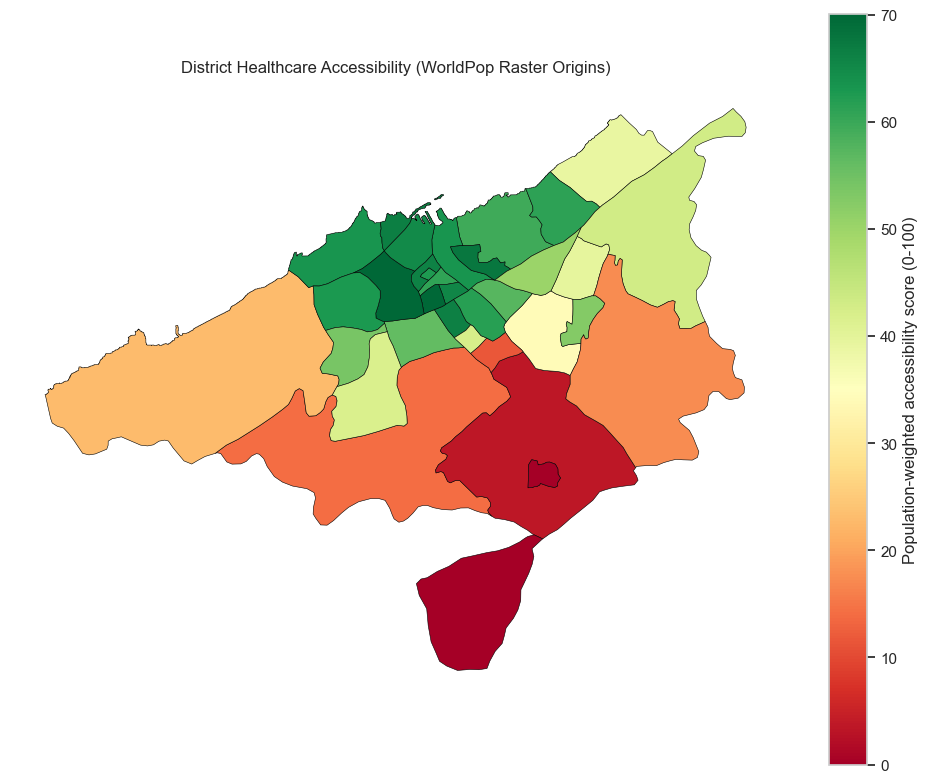

In [32]:
fig, ax = plt.subplots(figsize=(10, 8))
districts_out.plot(
    ax=ax,
    column="pop_weighted_accessibility_score",
    cmap="RdYlGn",
    legend=True,
    linewidth=0.4,
    edgecolor="black",
    legend_kwds={"label": "Population-weighted accessibility score (0-100)"},
)
ax.set_title("District Healthcare Accessibility (WorldPop Raster Origins)")
ax.set_axis_off()
plt.tight_layout()
plt.savefig(FIG_DIR / "district_accessibility_score.png", dpi=200, bbox_inches="tight")
plt.show()

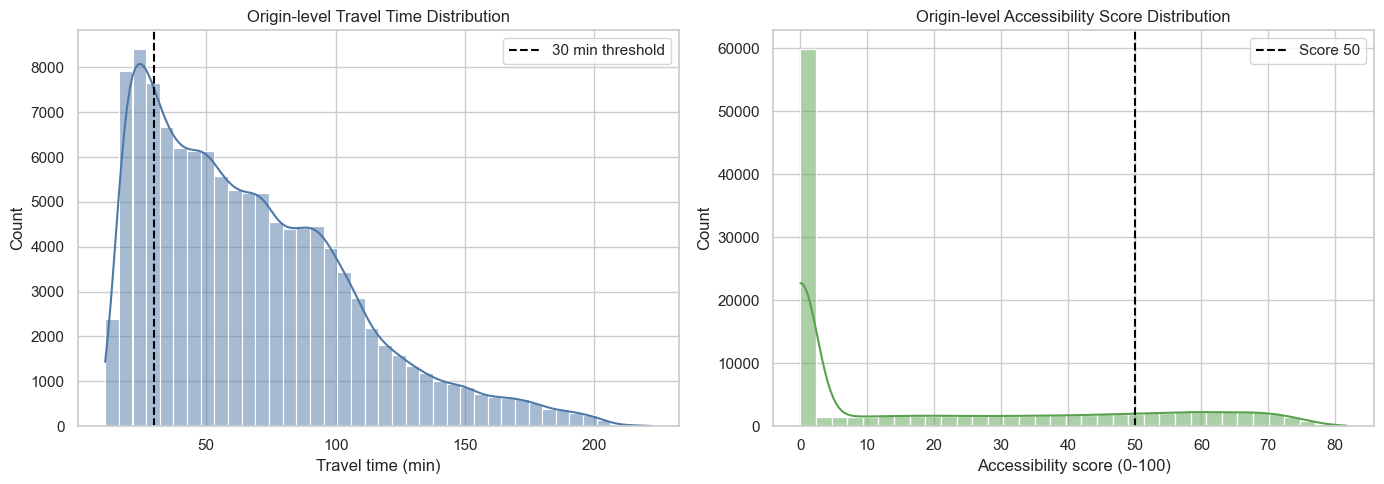

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(origins["total_travel_time_min"].dropna(), bins=40, kde=True, ax=axes[0], color="#4E79A7")
axes[0].axvline(cfg.threshold_min, color="black", linestyle="--", linewidth=1.5, label=f"{cfg.threshold_min:.0f} min threshold")
axes[0].set_title("Origin-level Travel Time Distribution")
axes[0].set_xlabel("Travel time (min)")
axes[0].legend()

sns.histplot(origins["accessibility_score"].dropna(), bins=35, kde=True, ax=axes[1], color="#59A14F")
axes[1].axvline(50, color="black", linestyle="--", linewidth=1.5, label="Score 50")
axes[1].set_title("Origin-level Accessibility Score Distribution")
axes[1].set_xlabel("Accessibility score (0-100)")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "origin_distributions.png", dpi=200, bbox_inches="tight")
plt.show()

## 11) Summary & Save outputs

In [34]:
print("--- Quick summary ---")
print(f"Districts loaded: {len(districts):,}")
print(f"Origins retained: {len(origins):,}")
print(f"Total retained population: {origins['population'].sum():,.2f}")
print(f"Graph nodes / edges: {G.number_of_nodes():,} / {G.number_of_edges():,}")
print()
print("District accessibility score stats:")
print(district_summary["pop_weighted_accessibility_score"].describe())
print()
print("Top 10 districts by accessibility:")
display(district_summary.head(10))

--- Quick summary ---
Districts loaded: 34
Origins retained: 117,107
Total retained population: 4,285,216.00
Graph nodes / edges: 42,323 / 44,746

District accessibility score stats:
count    34.000000
mean     47.398153
std      21.890597
min       0.000000
25%      39.052517
50%      56.793309
75%      63.302392
max      70.018722
Name: pop_weighted_accessibility_score, dtype: float64

Top 10 districts by accessibility:


,district_id,district_name,population_raster,origin_count,avg_walk_time_to_stop_min_pw,avg_total_travel_time_min_pw,pop_weighted_accessibility_score,pop_weighted_score_2sfca,pct_pop_access_threshold,pct_pop_score_below_50
5,13,Bou Chentouf,29411.693359,322.0,3.833672,17.988767,70.018722,0.000058,99.999999,0.000000
6,14,El Maarif,137460.062500,1776.0,4.482419,18.007699,69.987169,0.000069,99.943519,0.056486
8,16,Hay Mohammadi,91473.882812,637.0,4.841141,19.447728,67.587120,0.000028,98.814650,1.185351
15,22,Moulay Youssef,14125.606445,503.0,4.799535,20.002301,66.668828,0.000075,95.935520,4.064480
4,12,Ben Msick,84406.671875,479.0,3.153777,20.237733,66.270444,0.000035,99.773507,0.226492
13,20,Mers Sultan,17214.408203,286.0,4.421337,20.335551,66.107414,0.000069,99.999996,0.000000
33,9,Al Idrissia,27723.011719,249.0,3.738809,20.674167,65.543054,0.000042,99.999997,0.000000
19,26,Sidi Belyout,65050.007812,1167.0,4.660947,20.981568,65.030720,0.000069,92.694070,7.305924
3,11,Assoukhour Assawda,145178.093750,1207.0,4.551923,22.007445,63.320924,0.000041,94.986086,5.013911
2,10,Anfa,73818.453125,2543.0,5.318311,22.051924,63.246794,0.000064,87.211974,12.788025


In [35]:
origins.to_file(ORIGINS_GPKG_PATH, layer="origins", driver="GPKG")
origins_export = origins.drop(columns="geometry").copy()
finite_cleanup_cols = [
    c for c in [
        "walk_dist_to_stop_m",
        "walk_time_to_stop_min",
        "total_travel_time_min",
        "tt_slow",
        "tt_base",
        "tt_fast",
    ] if c in origins_export.columns
]
if finite_cleanup_cols:
    origins_export[finite_cleanup_cols] = origins_export[finite_cleanup_cols].replace([np.inf, -np.inf], np.nan)
origins_export.to_csv(ORIGINS_CSV_PATH, index=False)
origins_export.to_csv(ORIGIN_METRICS_CSV_PATH, index=False)

district_summary.to_csv(DISTRICT_SUMMARY_CSV_PATH, index=False)
districts_out.to_file(DISTRICT_SUMMARY_GPKG_PATH, layer="district_summary", driver="GPKG")

print("Saved:")
print(" -", ORIGINS_GPKG_PATH)
print(" -", ORIGINS_CSV_PATH)
print(" -", ORIGIN_METRICS_CSV_PATH)
print(" -", DISTRICT_SUMMARY_CSV_PATH)
print(" -", DISTRICT_SUMMARY_GPKG_PATH)


Saved:
 - D:\Capstone\capstone_repo\data\interim\worldpop_origins.gpkg
 - D:\Capstone\capstone_repo\data\interim\worldpop_origins.csv
 - D:\Capstone\capstone_repo\data\interim\origin_accessibility_metrics.csv
 - D:\Capstone\capstone_repo\data\final\district_accessibility_summary.csv
 - D:\Capstone\capstone_repo\data\final\district_accessibility_summary.gpkg
